# Heart Failure Dataset: EDA

This notebook explores the Kaggle Heart Failure Prediction dataset. The goal is to describe the data, check data quality, and identify the variables most strongly associated with `HeartDisease`.


## Feature Reference

- `Age`: patient age in years
- `Sex`: `M` or `F`
- `ChestPainType`: `TA` typical angina, `ATA` atypical angina, `NAP` non-anginal pain, `ASY` asymptomatic
- `RestingBP`: resting blood pressure in mm Hg
- `Cholesterol`: serum cholesterol in mm/dl
- `FastingBS`: `1` if fasting blood sugar is above 120 mg/dl, else `0`
- `RestingECG`: `Normal`, `ST`, `LVH`
- `MaxHR`: maximum heart rate achieved
- `ExerciseAngina`: exercise-induced angina, `Y` or `N`
- `Oldpeak`: ST depression induced by exercise relative to rest
- `ST_Slope`: slope of the peak exercise ST segment, `Up`, `Flat`, `Down`
- `HeartDisease`: target, `1` means heart disease and `0` means no heart disease


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")


In [5]:
df = pd.read_csv("heart.csv")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 918
Columns: 12


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.500,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.000,Up,0


In [6]:
df.dtypes.rename("dtype").to_frame()

,dtype
Age,int64
Sex,str
ChestPainType,str
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,str
MaxHR,int64
ExerciseAngina,str
Oldpeak,float64


In [8]:
df.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
Age,53.511,9.433,28.000,54.000,77.000
RestingBP,132.397,18.514,0.000,130.000,200.000
Cholesterol,198.800,109.384,0.000,223.000,603.000
FastingBS,0.233,0.423,0.000,0.000,1.000
MaxHR,136.809,25.460,60.000,138.000,202.000
Oldpeak,0.887,1.067,-2.600,0.600,6.200
HeartDisease,0.553,0.497,0.000,1.000,1.000


## Data Quality

There are no formal missing values or duplicate rows. The main issue is a large block of zero values in `Cholesterol` and one zero value in `RestingBP`, which look like placeholder values rather than realistic measurements.


In [10]:
quality = pd.DataFrame(
    {
        "metric": ["duplicate rows", "missing values", "RestingBP == 0", "Cholesterol == 0"],
        "value": [
            df.duplicated().sum(),
            df.isna().sum().sum(),
            (df["RestingBP"] == 0).sum(),
            (df["Cholesterol"] == 0).sum(),
        ],
    }
)
quality

,metric,value
0,duplicate rows,0
1,missing values,0
2,RestingBP == 0,1
3,Cholesterol == 0,172


In [11]:
zero_flags = pd.DataFrame(
    {
        "count": [(df["RestingBP"] == 0).sum(), (df["Cholesterol"] == 0).sum()],
        "share": [(df["RestingBP"] == 0).mean(), (df["Cholesterol"] == 0).mean()],
    },
    index=["RestingBP == 0", "Cholesterol == 0"],
)
zero_flags

,count,share
RestingBP == 0,1,0.001
Cholesterol == 0,172,0.187


In [12]:
cholesterol_check = pd.DataFrame(
    {
        "raw_median": df.groupby("HeartDisease")["Cholesterol"].median(),
        "positive_only_median": df.loc[df["Cholesterol"] > 0].groupby("HeartDisease")["Cholesterol"].median(),
    }
)
cholesterol_check

,raw_median,positive_only_median
HeartDisease,,
0,227.000,231.500
1,217.000,246.000


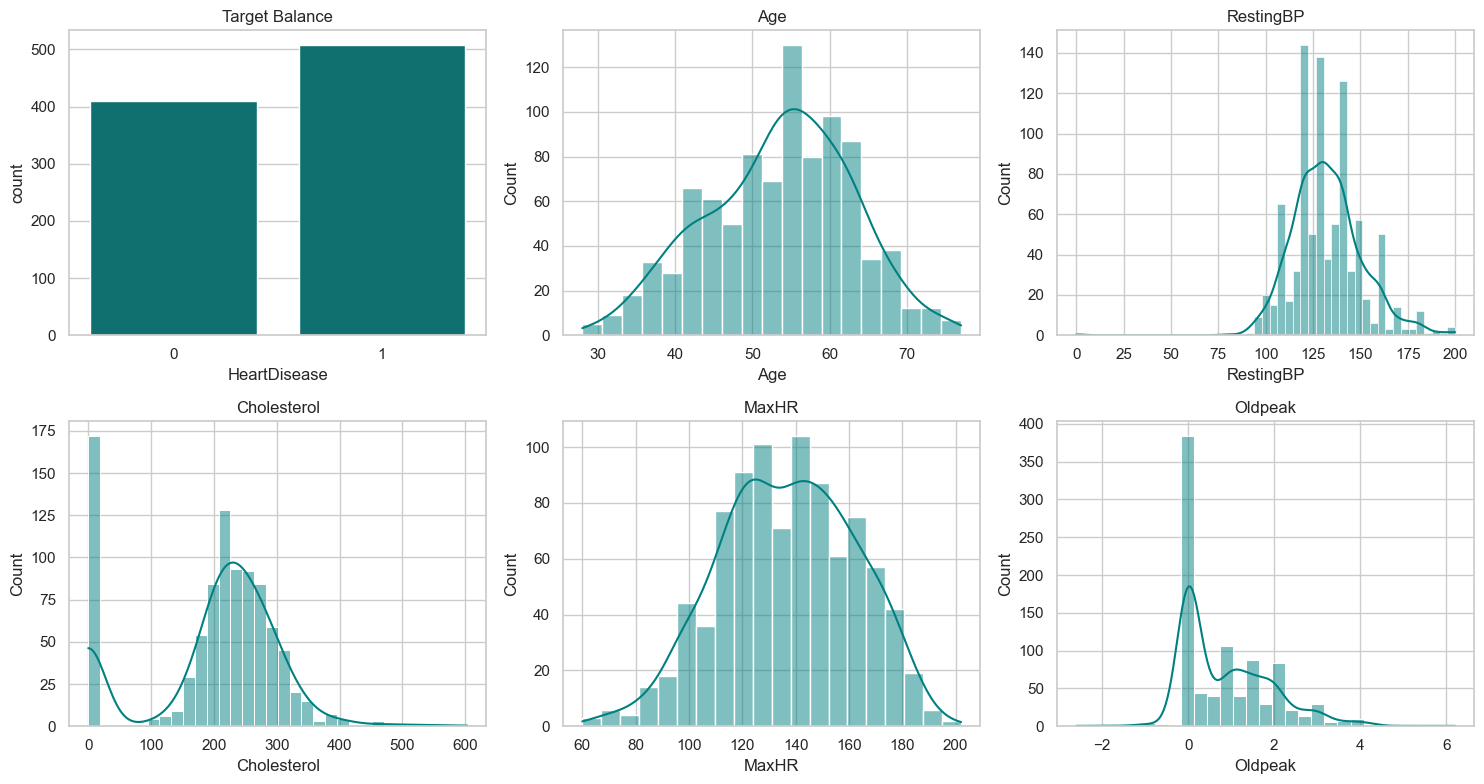

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.countplot(data=df, x="HeartDisease", ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Target Balance")

for ax, col in zip(axes.flat[1:], ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="teal")
    ax.set_title(col)

plt.tight_layout()
plt.show()


The dataset is slightly imbalanced toward heart disease cases. `Age`, `MaxHR`, and `Oldpeak` already look informative, while `Cholesterol` is visibly distorted by the zero values.


In [15]:
cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

cat_summary = pd.concat(
    [
        df.groupby(col)["HeartDisease"].agg(rate="mean", count="size").reset_index().rename(columns={col: "level"}).assign(feature=col)
        for col in cat_cols
    ],
    ignore_index=True,
)
cat_summary[["feature", "level", "rate", "count"]].sort_values(["feature", "rate"], ascending=[True, False])

,feature,level,rate,count
2,ChestPainType,ASY,0.790,496
5,ChestPainType,TA,0.435,46
4,ChestPainType,NAP,0.355,203
3,ChestPainType,ATA,0.139,173
12,ExerciseAngina,Y,0.852,371
11,ExerciseAngina,N,0.351,547
7,FastingBS,1,0.794,214
6,FastingBS,0,0.480,704
10,RestingECG,ST,0.657,178
8,RestingECG,LVH,0.564,188


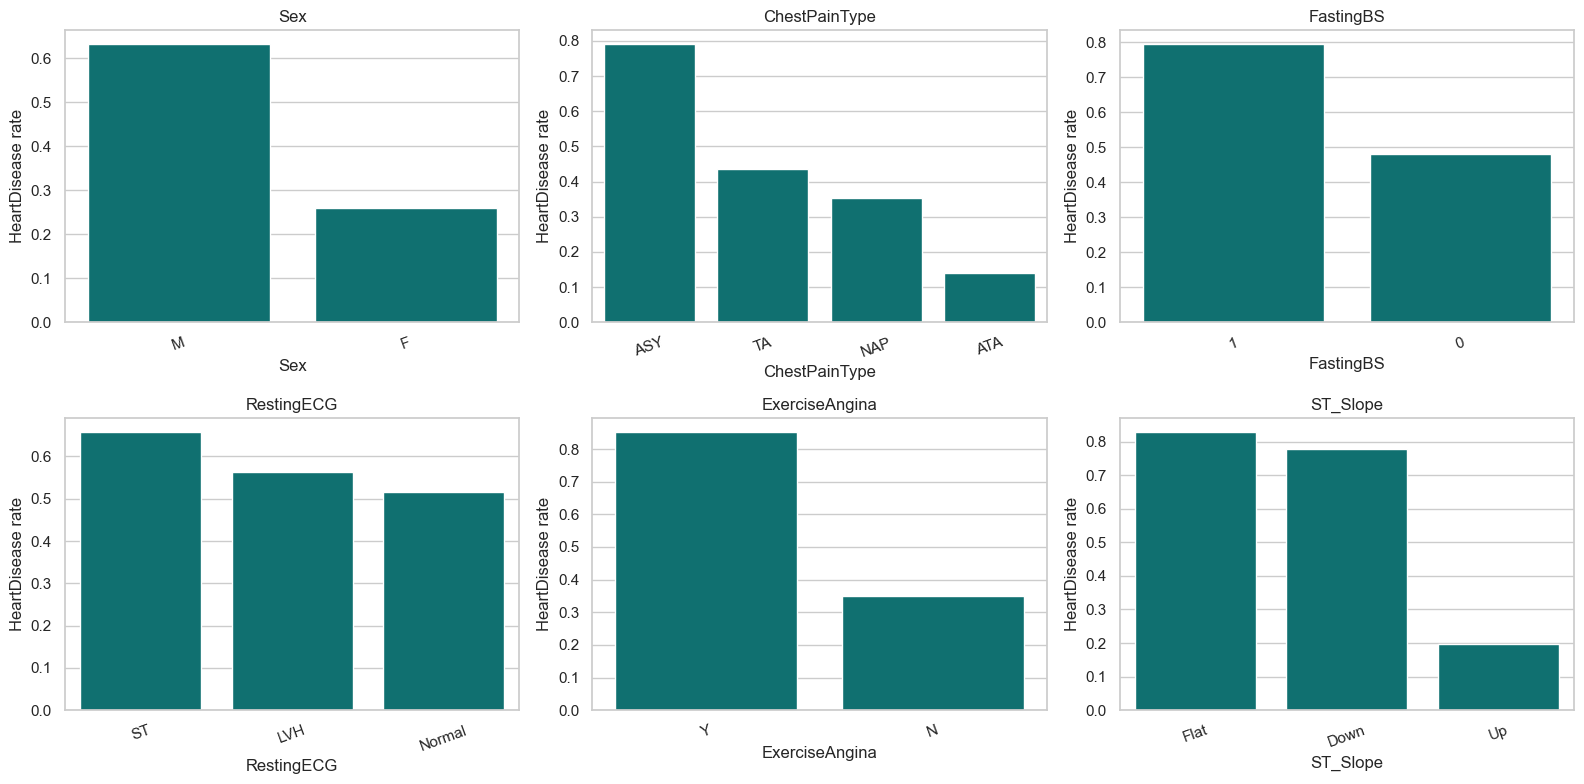

In [16]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cat_cols):
    order = df.groupby(col)["HeartDisease"].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y="HeartDisease", order=order, errorbar=None, ax=ax, color="teal")
    ax.set_title(col)
    ax.set_ylabel("HeartDisease rate")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


The clearest categorical signals are `ExerciseAngina`, `ST_Slope`, and `ChestPainType`. The disease rate is highest for `ExerciseAngina=Y`, `ST_Slope=Flat` or `Down`, and `ChestPainType=ASY`. Men also have a much higher disease rate than women.


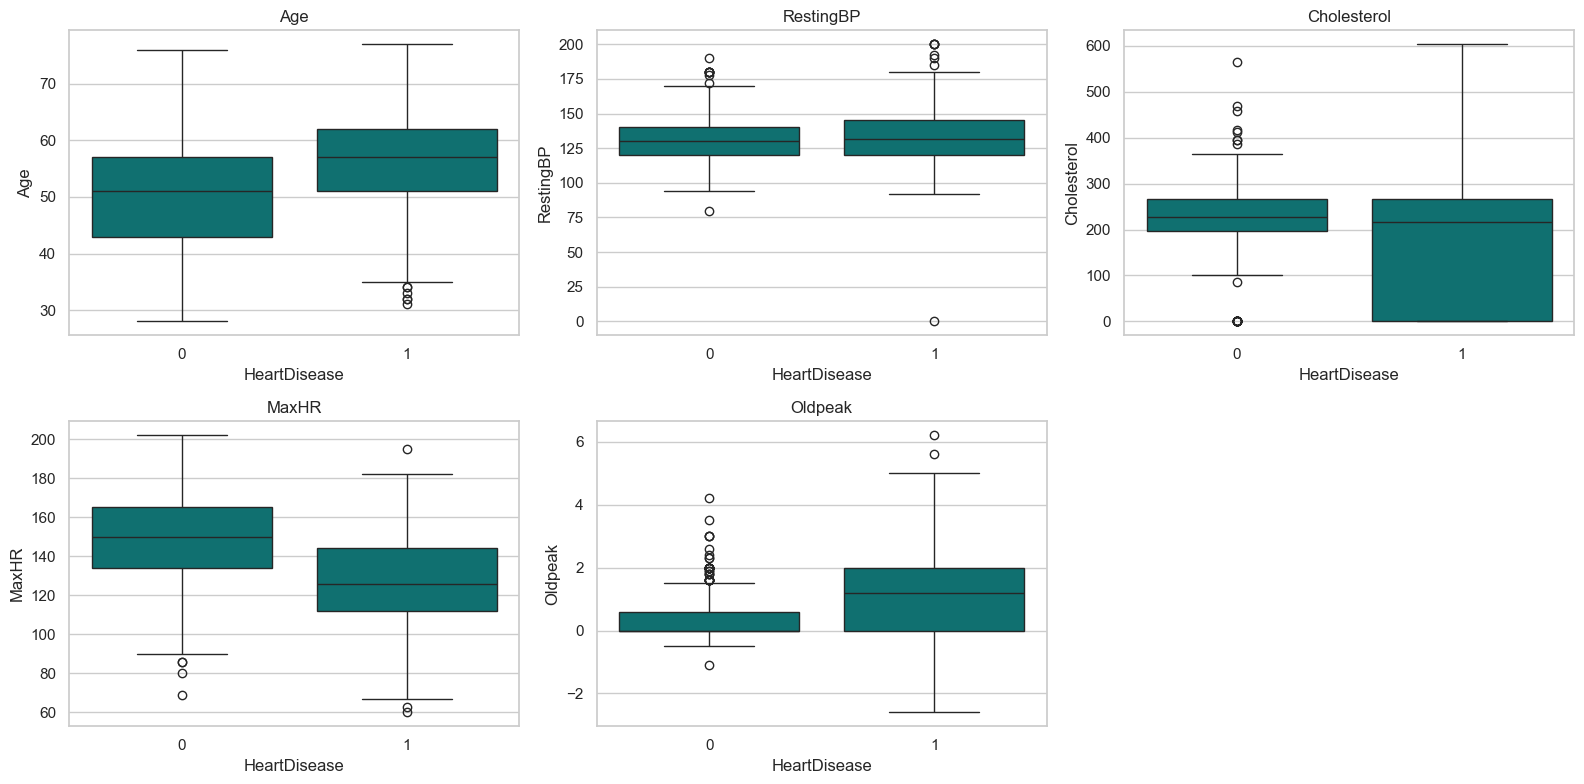

HeartDisease,no_disease,disease
Age,51.000,57.000
RestingBP,130.000,132.000
Cholesterol,227.000,217.000
MaxHR,150.000,126.000
Oldpeak,0.000,1.200


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]):
    sns.boxplot(data=df, x="HeartDisease", y=col, ax=ax, color="teal")
    ax.set_title(col)

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

num_summary = df.groupby("HeartDisease")[["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]].median().T
num_summary.rename(columns={0: "no_disease", 1: "disease"})

Cases with heart disease tend to be older, have lower `MaxHR`, and higher `Oldpeak`. `RestingBP` shifts only slightly. Raw `Cholesterol` is hard to interpret because many zero values fall into the positive class.


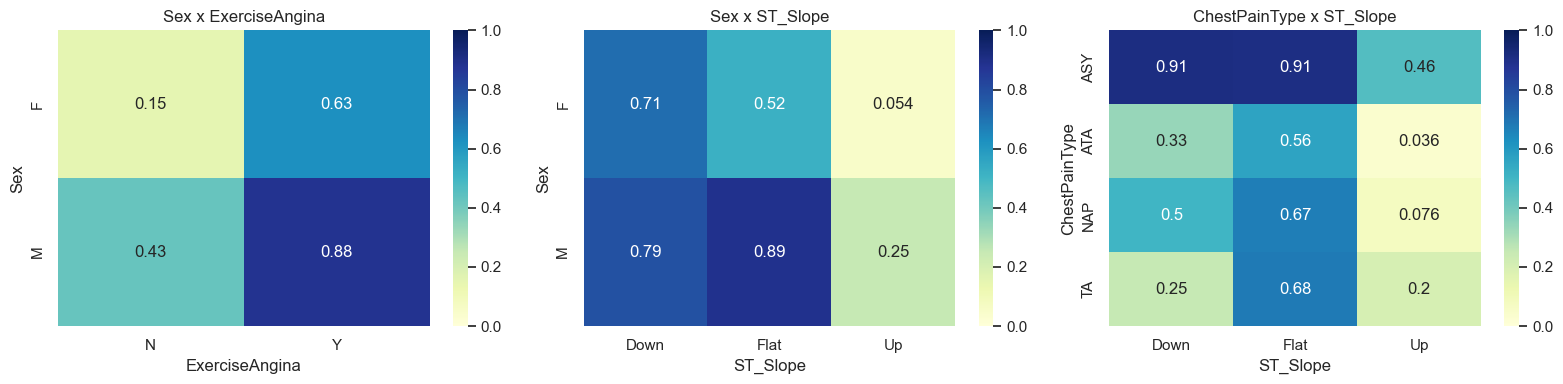

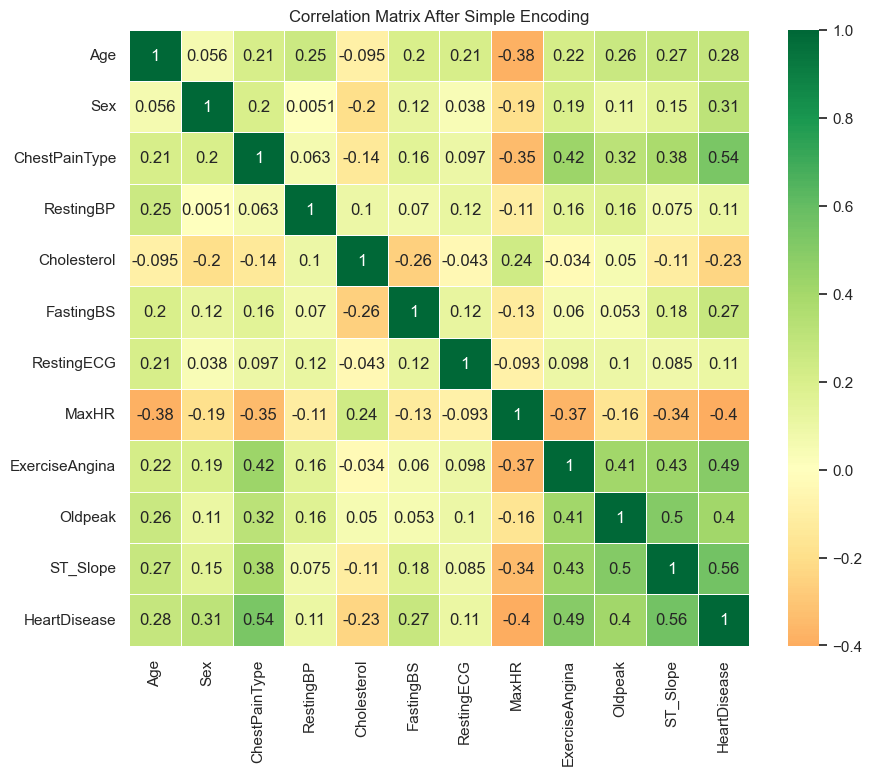

In [19]:
encoded = df.copy()
encoded["Sex"] = encoded["Sex"].map({"F": 0, "M": 1})
encoded["ExerciseAngina"] = encoded["ExerciseAngina"].map({"N": 0, "Y": 1})
encoded["ChestPainType"] = encoded["ChestPainType"].map({"ATA": 0, "NAP": 1, "TA": 2, "ASY": 3})
encoded["RestingECG"] = encoded["RestingECG"].map({"Normal": 0, "LVH": 1, "ST": 2})
encoded["ST_Slope"] = encoded["ST_Slope"].map({"Up": 0, "Flat": 1, "Down": 2})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(
    df.pivot_table(index="Sex", columns="ExerciseAngina", values="HeartDisease", aggfunc="mean"),
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Sex x ExerciseAngina")

sns.heatmap(
    df.pivot_table(index="Sex", columns="ST_Slope", values="HeartDisease", aggfunc="mean"),
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title("Sex x ST_Slope")

sns.heatmap(
    df.pivot_table(index="ChestPainType", columns="ST_Slope", values="HeartDisease", aggfunc="mean"),
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=axes[2],
)
axes[2].set_title("ChestPainType x ST_Slope")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(encoded.corr(numeric_only=True), annot=True, cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix After Simple Encoding")
plt.show()


Risk becomes especially high when several strong signals appear together, for example male patients with exercise angina, flat or down `ST_Slope`, or asymptomatic chest pain. The correlation heatmap supports the same picture: `Oldpeak`, `MaxHR`, and the exercise-related variables carry the strongest signal.


In [20]:
preprocessing_plan = pd.DataFrame(
    [
        ["Sex", "binary encode", "already binary"],
        ["ExerciseAngina", "binary encode", "already binary"],
        ["FastingBS", "keep as binary", "already 0 or 1"],
        ["ChestPainType", "one-hot encode", "nominal categories"],
        ["RestingECG", "one-hot encode", "nominal categories"],
        ["ST_Slope", "one-hot encode", "strong categorical signal"],
        ["Age", "keep numeric", "scale for linear models if needed"],
        ["MaxHR", "keep numeric", "scale for linear models if needed"],
        ["Oldpeak", "keep numeric", "strong continuous signal"],
        ["Cholesterol", "treat zeros as missing or add a zero flag", "raw zeros distort the feature"],
        ["RestingBP", "inspect the single zero and treat it as missing", "likely invalid value"],
    ],
    columns=["feature", "suggestion", "reason"],
)
preprocessing_plan

,feature,suggestion,reason
0,Sex,binary encode,already binary
1,ExerciseAngina,binary encode,already binary
2,FastingBS,keep as binary,already 0 or 1
3,ChestPainType,one-hot encode,nominal categories
4,RestingECG,one-hot encode,nominal categories
5,ST_Slope,one-hot encode,strong categorical signal
6,Age,keep numeric,scale for linear models if needed
7,MaxHR,keep numeric,scale for linear models if needed
8,Oldpeak,keep numeric,strong continuous signal
9,Cholesterol,treat zeros as missing or add a zero flag,raw zeros distort the feature


## Conclusions

- The dataset has no formal missing values, but `Cholesterol` contains many zero placeholders and `RestingBP` has one suspicious zero.
- The target is slightly skewed toward positive cases.
- The strongest categorical signals are `ExerciseAngina`, `ST_Slope`, `ChestPainType`, and `Sex`.
- The strongest numeric signals are `Oldpeak`, `MaxHR`, and `Age`.
- `RestingBP` looks relatively weak on its own.
- Before modeling, the main preprocessing step is handling suspicious zeros and encoding nominal categorical variables.
